# Combination of Numerical Model and Observations to Improve Machine Learning Predictions in a Chaotic System

This notebook explores how combining sparse, noisy observations, imperfect numerical model outputs can improve the outputs of machine learning model of a chaotic environment using the Lorenz system. 

GitHub Copilot was used to generate part of the code .

The lorenz.yaml file provided alongside the notebook can be used to install the conda environment for running the notebook.

# Notebook Overview
This notebook explores the combination of different data sources to build machine learning models for chaotic systems. The key steps and data sources include:
- **Data Sources**:
  - Ground truth data from the Lorenz system.
  - Sparse and noisy observations sampled from ground truth.
  - Imperfect numerical model outputs.
- **Objective**: Investigate how combining these data sources can improve machine learning predictions.
- **Synthetic Dataset**:
  - Use the Lorenz system to generate synthetic data.
  - Introduce noise and sparsity to simulate real-world scenarios.
  - Create an imperfect numerical model with parameter errors.
- **Data Preparation**:
  - Normalize and preprocess the data.
  - Split the data into training, validation, and test sets.
- **Modeling**:
  - Train LSTM models using individual and combined data sources.
  - Evaluate model performance on unseen data from a common test dataset.
- **Visualization and Analysis**:
  - Plot loss functions to understand training dynamics.
  - Compare predictions from different models against ground truth.
This exercise demonstrates the benefits of combining diverse data sources for machine learning in chaotic systems.

# 1. Import Required Libraries

Import libraries such as NumPy, SciPy, Matplotlib, TensorFlow/PyTorch, and others for numerical modeling, data processing, and machine learning.  

In [1]:
# Import Required Libraries
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import random

# Note that the notebook uses random sampling for noisy observations. 
# random seeds are set for reproducibility 
random.seed(42)  # Python's random module
np.random.seed(42)  # NumPy
tf.random.set_seed(42)  # TensorFlow

2026-03-31 12:52:30.810401: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 2. Simulate the Ground Truth System (Lorenz System)

Use an accurate ODE solver to simulate the Lorenz system and generate reference data for the chaotic environment.

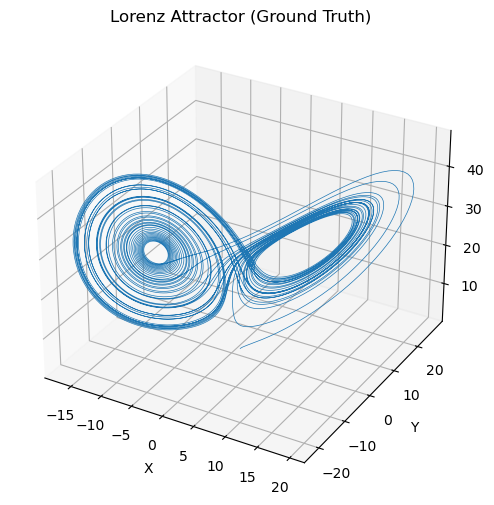

In [2]:
# Define the Lorenz system
def lorenz_system(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Simulate the Lorenz system
t_span = (0, 50)  # Time range
initial_state = [1.0, 1.0, 1.0]  # Initial conditions
t_eval = np.linspace(t_span[0], t_span[1], 10000)  # Time points for evaluation

solution = solve_ivp(lorenz_system, t_span, initial_state, t_eval=t_eval)

# Extract the solution
t = solution.t
x, y, z = solution.y

# Plot the Lorenz attractor
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.5)
ax.set_title("Lorenz Attractor (Ground Truth)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# 3. Create the Imperfect Numerical Model

Question 1 : How can we create an imperfect numerical model of the Lorenz system? 

Imperfect model can be created introducing parameter errors or reducing resolution. In this case we try using the parameters sigma=12.0, rho=25.0, beta=2.5 and observe the differences in the system's behavior.

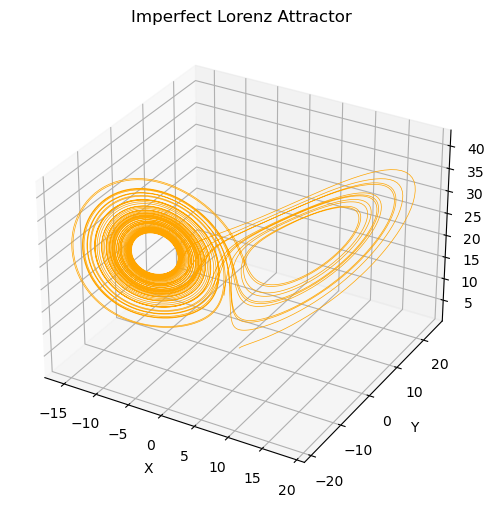

In [3]:
# Define an imperfect Lorenz system with parameter errors
def imperfect_lorenz_system(t, state, sigma=12.0, rho=25.0, beta=2.5):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Simulate the imperfect Lorenz system
imperfect_solution = solve_ivp(imperfect_lorenz_system, t_span, initial_state, t_eval=t_eval)

# Extract the solution
x_imp, y_imp, z_imp = imperfect_solution.y

# Plot the imperfect Lorenz attractor
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x_imp, y_imp, z_imp, lw=0.5, color='orange')
ax.set_title("Imperfect Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# 4. Generate Sparse and Noisy Observations

Question 2: How can we generate sparse and noisy observations from the ground truth data? 

Consider sampling the data sparsely and adding noise to mimic real-world measurement limitations. Think about the number of samples to take and the level of noise to introduce.

In the example proposed, a subset of the ground truth data is selected by randomly sampling 500 indices to create sparse observations. Then, Gaussian noise with a mean of 0 and a standard deviation of 2.0 was added to the x, y, and z coordinates of the sampled data points. This process simulates real-world scenarios where measurements are both limited and noisy.

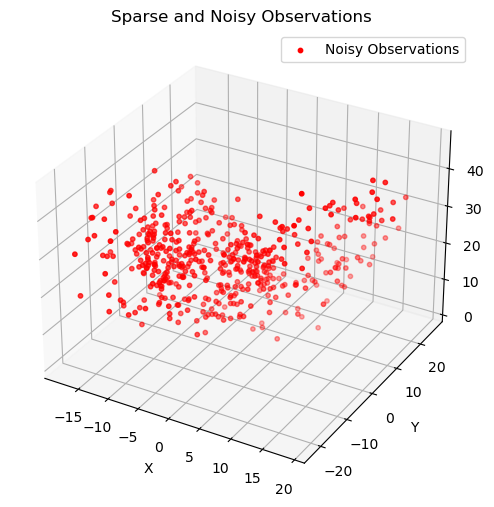

In [4]:
# Generate sparse and noisy observations

num_samples = 500  # Number of sparse samples
indices = sorted(random.sample(range(len(t)), num_samples))  # Randomly select indices
t_sparse = t[indices]
x_sparse = x[indices] + np.random.normal(0, 2.0, num_samples)  # Add noise
y_sparse = y[indices] + np.random.normal(0, 2.0, num_samples)
z_sparse = z[indices] + np.random.normal(0, 2.0, num_samples)

# Plot sparse and noisy observations
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(x_sparse, y_sparse, z_sparse, c='red', s=10, label='Noisy Observations')
ax.set_title("Sparse and Noisy Observations")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

# 5. Build Machine Learning Models to Predict the Lorenz System

Question 3: How can we build and train machine learning models to predict the Lorenz system?

Try using different data sources such as ground truth,  sparse observations, imperfect numerical model outputs, or a combination of the sources. Consider how to define the model architecture, preprocess the data, and evaluate the model's performance.

The Lorenz system generates sequential data with temporal dependencies. In this example we will use LSTMs (Long Short-Term Memory networks) .  LSTMs are specifically designed to handle time-series data by capturing patterns over time.

In [5]:
# Import additional libraries for data preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Define the sequence length for LSTM input
sequence_length = 50

# Define and compile the LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        LSTM(64, activation='tanh'),
        Dense(3)  # Predict x, y, z
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Helper function to create sequences for time-series prediction
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)


# 5.1 Preprocessing : Normalize the data
Normalization ensures that all features are on a similar scale, improving model training and convergence.
It also prevents features with larger scales from dominating the learning process.

In [6]:
scaler = MinMaxScaler()
ground_truth_scaled = scaler.fit_transform(np.column_stack((x, y, z)))
imperfect_scaled = scaler.transform(np.column_stack((x_imp, y_imp, z_imp)))
observations_scaled = scaler.transform(np.column_stack((x_sparse, y_sparse, z_sparse)))

# 5.2 Split the data in training, validation, and test sets

Create a function that splits the data into training (70%) validation (15%) and test (15%)

In [7]:
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
def split_data(X, y, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)
    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
    X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)



# 5.3 Training the models

In this section we will create :

a model based on observations only

a model based on imperfect model and ground truth

a model based on imperfect numerical model and sparse observations

In [8]:
# Model based on observations only
# Prepare datasets for training
X_obs, y_obs = create_sequences(observations_scaled, sequence_length)
# Split the datasets
(X_obs_train, y_obs_train), (X_obs_val, y_obs_val), (X_obs_test, y_obs_test) = split_data(X_obs, y_obs)
# Train the model using only observations
print("Training model with only observations...")
model_obs = build_lstm_model((sequence_length, 3))
history_obs = model_obs.fit(X_obs_train, y_obs_train, validation_data=(X_obs_val, y_obs_val), epochs=20, batch_size=32, verbose=1)



Training model with only observations...
Epoch 1/20
10/10 [==============================] - 4s 98ms/step - loss: 0.0653 - val_loss: 0.0450
Epoch 2/20
10/10 [==============================] - 0s 34ms/step - loss: 0.0321 - val_loss: 0.0394
Epoch 3/20
10/10 [==============================] - 0s 39ms/step - loss: 0.0296 - val_loss: 0.0393
Epoch 4/20
10/10 [==============================] - 0s 34ms/step - loss: 0.0293 - val_loss: 0.0384
Epoch 5/20
10/10 [==============================] - 0s 33ms/step - loss: 0.0289 - val_loss: 0.0396
Epoch 6/20
10/10 [==============================] - 0s 34ms/step - loss: 0.0280 - val_loss: 0.0376
Epoch 7/20
10/10 [==============================] - 0s 35ms/step - loss: 0.0275 - val_loss: 0.0368
Epoch 8/20
10/10 [==============================] - 0s 34ms/step - loss: 0.0272 - val_loss: 0.0388
Epoch 9/20
10/10 [==============================] - 0s 34ms/step - loss: 0.0269 - val_loss: 0.0367
Epoch 10/20
10/10 [==============================] - 0s 34ms/step - 

In [9]:
# Model based on combination of ground truth and imperfect model
# Prepare datasets for training
X_ground_truth, y_ground_truth = create_sequences(ground_truth_scaled, sequence_length)
X_imperfect, y_imperfect = create_sequences(imperfect_scaled, sequence_length)
X_combined = np.concatenate((X_ground_truth, X_imperfect), axis=0)
y_combined = np.concatenate((y_ground_truth, y_imperfect), axis=0)
# Split the datasets
(X_combined_train, y_combined_train), (X_combined_val, y_combined_val), (X_combined_test, y_combined_test) = split_data(X_combined, y_combined)
# Train the model using imperfect model and ground truth sources combined
print("Training model with imperfect model and ground truth sources combined...")
model_combined = build_lstm_model((sequence_length, 3))
history_combined = model_combined.fit(X_combined_train, y_combined_train, validation_data=(X_combined_val, y_combined_val), epochs=20, batch_size=32, verbose=1)



Training model with imperfect model and ground truth sources combined...
Epoch 1/20
436/436 [==============================] - 18s 34ms/step - loss: 0.0025 - val_loss: 3.8702e-05
Epoch 2/20
436/436 [==============================] - 14s 31ms/step - loss: 1.8948e-05 - val_loss: 2.4387e-05
Epoch 3/20
436/436 [==============================] - 14s 32ms/step - loss: 1.1231e-05 - val_loss: 2.1663e-05
Epoch 4/20
436/436 [==============================] - 13s 31ms/step - loss: 1.2952e-05 - val_loss: 1.7710e-05
Epoch 5/20
436/436 [==============================] - 14s 32ms/step - loss: 9.2579e-06 - val_loss: 2.2549e-05
Epoch 6/20
436/436 [==============================] - 14s 32ms/step - loss: 1.2606e-05 - val_loss: 2.0270e-05
Epoch 7/20
436/436 [==============================] - 13s 31ms/step - loss: 9.4658e-06 - val_loss: 1.2058e-05
Epoch 8/20
436/436 [==============================] - 14s 32ms/step - loss: 1.1366e-05 - val_loss: 9.1683e-06
Epoch 9/20
436/436 [==============================]

In [10]:
# Model based on combination of imperfect numerical model and sparse observations
# Combine imperfect numerical model and sparse observations
X_combined_obs_num = np.concatenate((X_imperfect, X_obs), axis=0)
y_combined_obs_num = np.concatenate((y_imperfect, y_obs), axis=0)

# Split the combined dataset
(X_combined_obs_num_train, y_combined_obs_num_train),(X_combined_obs_num_val, y_combined_obs_num_val),(X_combined_obs_num_test, y_combined_obs_num_test) = split_data(X_combined_obs_num, y_combined_obs_num)

# Train the model using imperfect numerical model and sparse observations
print("Training model with imperfect numerical model and sparse observations...")
model_combined_obs_num = build_lstm_model((sequence_length, 3))
history_combined_obs_num = model_combined_obs_num.fit(
    X_combined_obs_num_train, y_combined_obs_num_train,
    validation_data=(X_combined_obs_num_val, y_combined_obs_num_val),
    epochs=20, batch_size=32, verbose=1)

Training model with imperfect numerical model and sparse observations...
Epoch 1/20
228/228 [==============================] - 11s 35ms/step - loss: 0.0035 - val_loss: 1.7145e-04
Epoch 2/20
228/228 [==============================] - 7s 31ms/step - loss: 3.4485e-05 - val_loss: 7.2161e-05
Epoch 3/20
228/228 [==============================] - 7s 31ms/step - loss: 1.3156e-05 - val_loss: 5.0497e-05
Epoch 4/20
228/228 [==============================] - 7s 31ms/step - loss: 9.2570e-06 - val_loss: 1.9793e-05
Epoch 5/20
228/228 [==============================] - 7s 33ms/step - loss: 3.8067e-06 - val_loss: 9.3288e-06
Epoch 6/20
228/228 [==============================] - 7s 31ms/step - loss: 2.3626e-06 - val_loss: 4.5362e-06
Epoch 7/20
228/228 [==============================] - 7s 31ms/step - loss: 3.5597e-06 - val_loss: 2.9540e-06
Epoch 8/20
228/228 [==============================] - 7s 32ms/step - loss: 3.2088e-06 - val_loss: 5.7694e-06
Epoch 9/20
228/228 [==============================] - 7s 3

# 6. Analyse the training and validation loss curves.

Question 4: Can you plot the loss function of the models?

Think about how the loss function evolves over epochs. What can we understand about the training process and the performance of the models from the loss curves? 

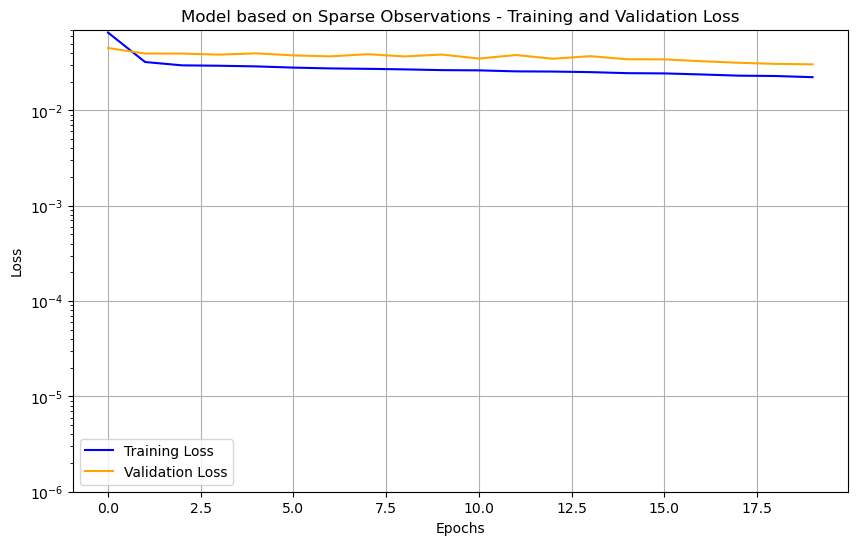

In [11]:
# Plot the loss function for the model trained on sparse observations
plt.figure(figsize=(10, 6))
plt.plot(history_obs.history['loss'], label='Training Loss', color='blue')
plt.plot(history_obs.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model based on Sparse Observations - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

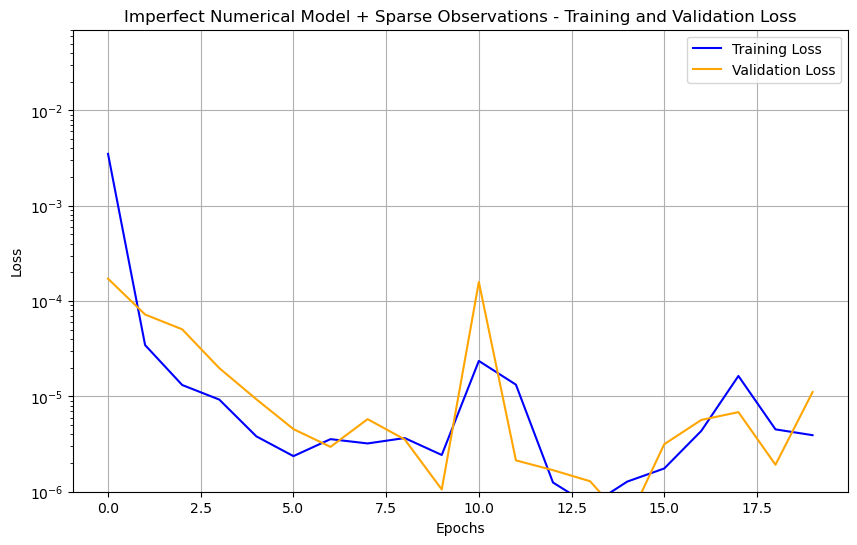

In [12]:
# Plot the loss function for the model trained on imperfect numerical model and sparse observations
plt.figure(figsize=(10, 6))
plt.plot(history_combined_obs_num.history['loss'], label='Training Loss', color='blue')
plt.plot(history_combined_obs_num.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Imperfect Numerical Model + Sparse Observations - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

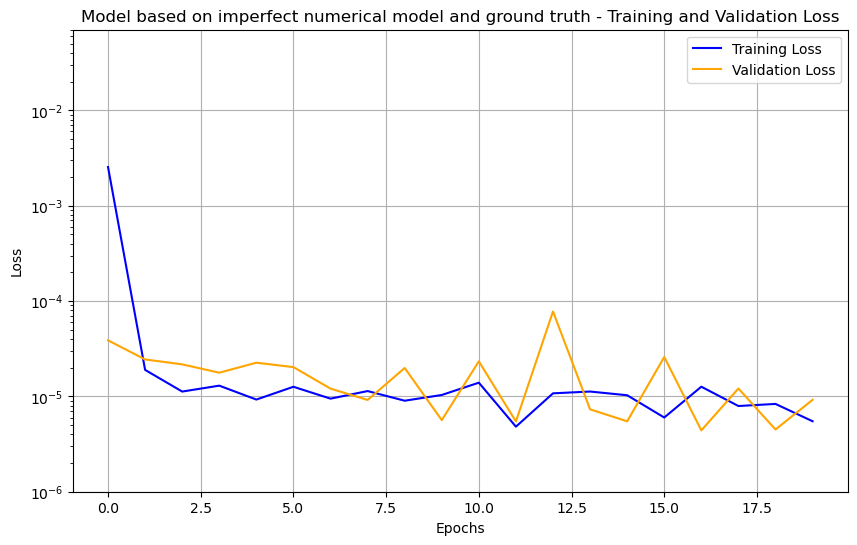

In [13]:
# Plot the loss function for the model trained on ground truth and imperfect numerical model combined
plt.figure(figsize=(10, 6))
plt.plot(history_combined.history['loss'], label='Training Loss', color='blue')
plt.plot(history_combined.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model based on imperfect numerical model and ground truth - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

Model trained on sparse observations only:
Training loss decreases steadily from 0.0653 to 0.0222, showing effective learning.
Validation loss fluctuates slightly but trends downward from 0.0449 to 0.0303, indicating moderate generalization.

Model trained on combined ground truth and imperfect numerical model:
Training loss starts at 0.0025 and drops to 0.0000055, reflecting excellent data fit.
Validation loss closely follows, decreasing from 0.0000387 to 0.0000092, showing excellent generalization.

Model trained on combined imperfect numerical model and sparse observations:
Training loss reduces rapidly from 0.0034 to 0.0000039, indicating strong learning.
Validation loss trends downward from 0.000171 to 0.0000011, demonstrating good generalization.

In [14]:
history_combined.history['val_loss']



[3.870175714837387e-05,
 2.4386836230405606e-05,
 2.166340345866047e-05,
 1.770974267856218e-05,
 2.2549244022229686e-05,
 2.0269904780434445e-05,
 1.2057695130351931e-05,
 9.168315955321305e-06,
 1.9842877009068616e-05,
 5.6351454986725e-06,
 2.3295531718758866e-05,
 5.452803634398151e-06,
 7.766022463329136e-05,
 7.312396064662607e-06,
 5.4733854994992726e-06,
 2.5883418857119977e-05,
 4.398513738124166e-06,
 1.2091293683624826e-05,
 4.494207587413257e-06,
 9.199869964504614e-06]

# Evaluate All Models on a Common Test Dataset

Question 5: Can we use the models to make a prediction on unseen data ?  We will use the models to predict unseen data from the test dataset. To ensure a fair comparison,we create a common test dataset derived only from the test portion of the ground truth data, avoiding overlap with training and validation data.

In [15]:
# Split the ground truth data into training, validation, and test sets
(X_ground_truth_train, y_ground_truth_train), \
(X_ground_truth_val, y_ground_truth_val), \
(X_ground_truth_test, y_ground_truth_test) = split_data(ground_truth_scaled, ground_truth_scaled, train_ratio=0.7, val_ratio=0.15)

# Create sequences for the test set only to ensure no overlap
X_common_test, y_common_test = create_sequences(X_ground_truth_test, sequence_length)

# Evaluate each model on the common test dataset
y_pred_obs = model_obs.predict(X_common_test)
y_pred_combined = model_combined.predict(X_common_test)
y_pred_combined_obs_num = model_combined_obs_num.predict(X_common_test)

# Compute Mean Squared Error (MSE) for each model
from sklearn.metrics import mean_squared_error
mse_obs = mean_squared_error(y_common_test, y_pred_obs)
mse_combined = mean_squared_error(y_common_test, y_pred_combined)
mse_combined_obs_num = mean_squared_error(y_common_test, y_pred_combined_obs_num)

print(f"MSE (Observations Model): {mse_obs}")
print(f"MSE (Combined Model): {mse_combined}")
print(f"MSE (Combined Obs + Imperfect Num Model): {mse_combined_obs_num}")

46/46 [==============================] - 1s 11ms/step
MSE (Observations Model): 0.012117543943136536
MSE (Combined Model): 1.0733147210023958e-05
MSE (Combined Obs + Imperfect Num Model): 8.20237499553677e-05


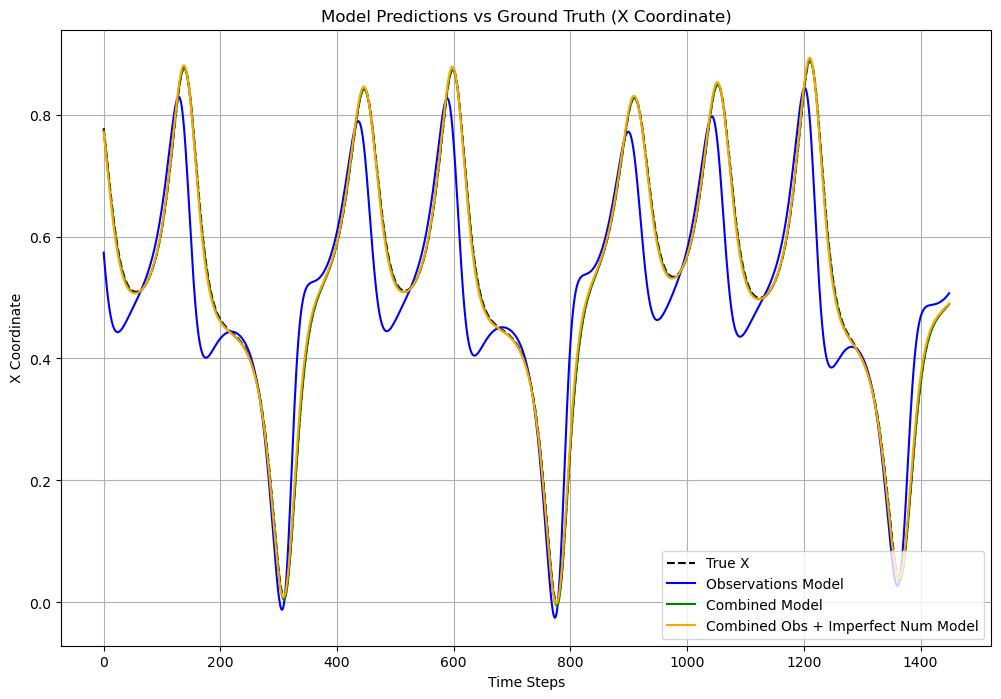

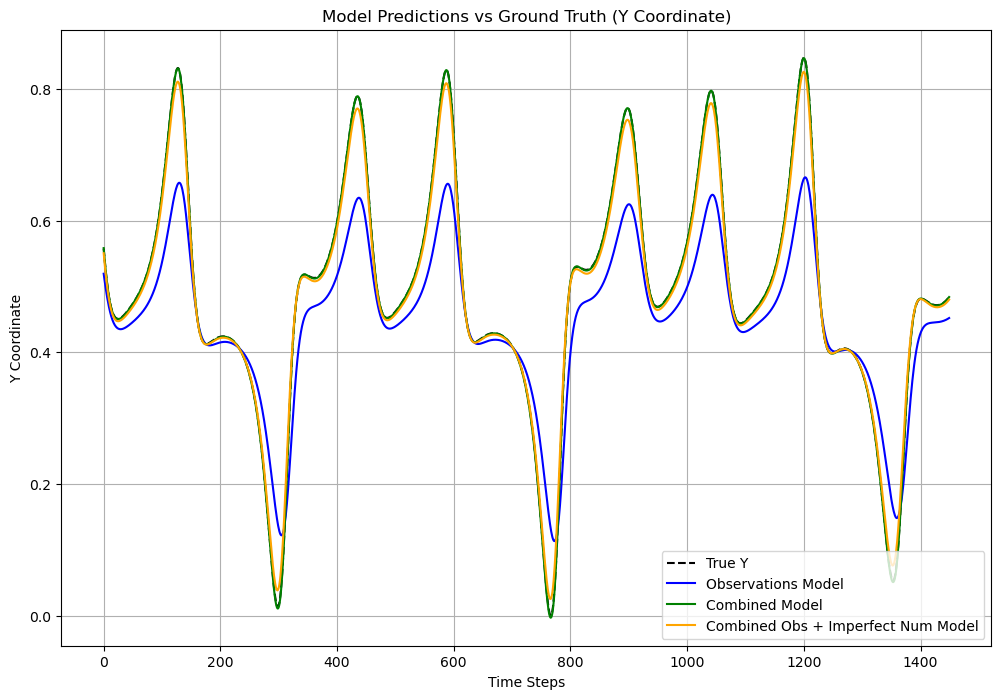

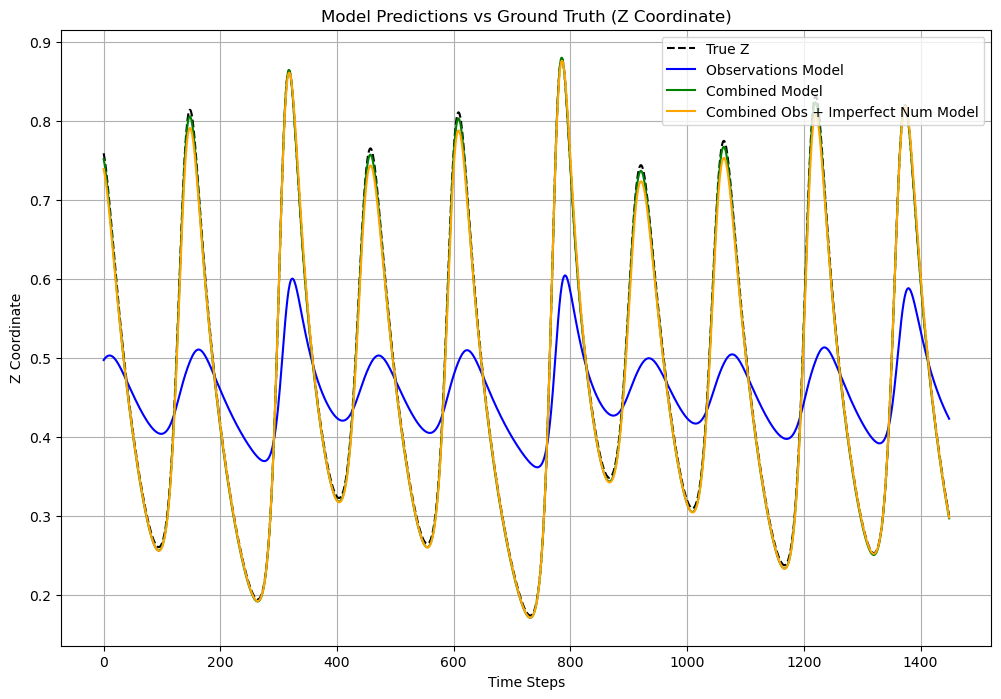

In [16]:
# Visualize predictions vs ground truth for the common test dataset (X Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 0], label='True X', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 0], label='Observations Model', color='blue')
plt.plot(y_pred_combined[:, 0], label='Combined Model', color='green')
plt.plot(y_pred_combined_obs_num[:, 0], label='Combined Obs + Imperfect Num Model', color='orange')

plt.title('Model Predictions vs Ground Truth (X Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('X Coordinate')
plt.legend()
plt.grid(True)
plt.show()

# Visualize predictions vs ground truth for the common test dataset (Y Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 1], label='True Y', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 1], label='Observations Model', color='blue')
plt.plot(y_pred_combined[:, 1], label='Combined Model', color='green')
plt.plot(y_pred_combined_obs_num[:, 1], label='Combined Obs + Imperfect Num Model', color='orange')

plt.title('Model Predictions vs Ground Truth (Y Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid(True)
plt.show()

# Visualize predictions vs ground truth for the common test dataset (Z Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 2], label='True Z', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 2], label='Observations Model', color='blue')
plt.plot(y_pred_combined[:, 2], label='Combined Model', color='green')
plt.plot(y_pred_combined_obs_num[:, 2], label='Combined Obs + Imperfect Num Model', color='orange')

plt.title('Model Predictions vs Ground Truth (Z Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True)
plt.show()

# What we learned:

Simulating Chaotic Systems: The Lorenz system demonstrates how to generate synthetic data for chaotic environments.

Choice of Architecture: LSTMs can be used for capturing temporal dependencies in time-series data. 

Data Preprocessing: Normalization and scaling of data are essential for improving model training and convergence.

Dataset Splitting: Splitting data into training, validation, and test sets ensures fair evaluation and prevent data leakage.

Combining Data Sources: Using diverse data sources, such as ground truth, sparse observations, and imperfect numerical models, to build different models.

Evaluating Loss Functions: Analysing training and validation loss curves helps in understanding model performance.

Make predictions on unseen data : the test data can be used to make predictions on unseen data.


# Limitations

We chose Long Short-Term Memory (LSTM) networks for this demonstration because they are well-suited for time-series prediction tasks, particularly in capturing temporal dependencies in sequential data (Hochreiter and Schmidhuber, 1997).

However,  LSTM can struggle with very long-term dependencies and require significant computational resources. Additionally, careful tuning of hyperparameters is essential for optimal performance. Alternative architectures, such as Transformers, may outperform LSTMs in certain scenarios. This notebook is intended as a demonstration of combining diverse data sources to improve machine learning predictions in chaotic systems. The focus is on illustrating the methodology rather than achieving state-of-the-art performance.

References:
1. Lorenz, E. N. (1963). Deterministic nonperiodic flow. Journal of the Atmospheric Sciences, 20(2), 130-141.
2. Hochreiter, Sepp, and Jürgen Schmidhuber (1997). "Long Short-Term Memory." Neural Computation 9(8), 1735–80. DOI:10.1162/neco.1997.9.8.1735

    